In [95]:
import torch
from torch import nn
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [96]:
#Pick Dataset

use_fashion_mnist = True

if use_fashion_mnist:
    training_data = datasets.FashionMNIST(
        root="data",
        train = True,
        download=True,
        transform=ToTensor()
    )
    test_data= datasets.FashionMNIST(
        root="data",
        train= False,
        download=True,
        transform=ToTensor()
    )
else:
    training_data = datasets.MNIST(
        root="data",
        train = True,
        download=True,
        transform=ToTensor()
    )
    test_data= datasets.MNIST(
        root="data",
        train= False,
        download=True,
        transform=ToTensor()
    )
    

In [97]:
#Laod the data
batchsize = 64

train_dataloader=DataLoader(training_data,batch_size = batchsize)
test_dataloader = DataLoader(test_data,batch_size = batchsize)


for X,y in test_dataloader:
    print(f"Shape of X [N, c , H, W]{X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, c , H, W]torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


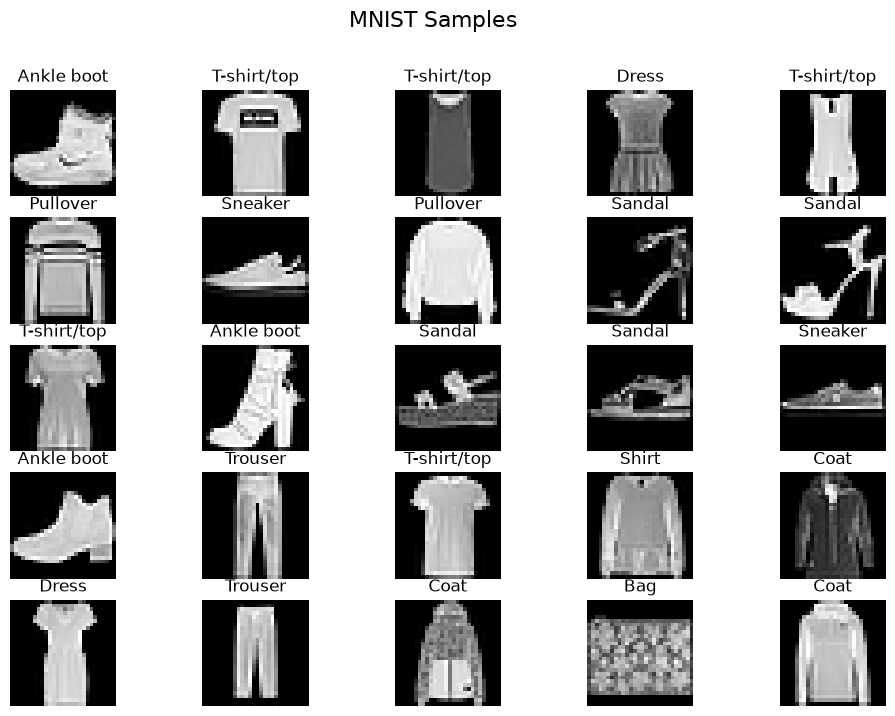

In [98]:

#Visualize the Data
rows = 5
cols = 5
samples_to_vis = rows*cols

fig,axes = plt.subplots (rows, cols, figsize= (12, 8))
fig.suptitle("MNIST Samples", fontsize = 16)

for i in range(samples_to_vis):
    row = i//cols
    col = i % cols

    image,label = training_data[i]
    class_name = training_data.classes[label]
    axes[row,col].imshow(image.squeeze(),cmap= "grey")
    axes[row,col].axis("off")
    axes[row,col].set_title(class_name,fontsize=12)

In [99]:
device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)
print(f"using {device} device")


using cpu device


In [100]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten() #flatten the 28*28 image into 1d array of greyscale values
        self.linear_relu_stack = nn.Sequential( #create the network with input of the flattened and output of 10 digits
            nn.Linear(28*28,256),
            nn.ReLU(),
            nn.Linear(256,512),
            nn.ReLU(),
            nn.Linear(512,10)
        )
    def forward(self,x):
        x= self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)

In [101]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr = 1e-2)



In [102]:

def train(dataloader,model,loss_fn,optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X,y) in enumerate(dataloader):
        X,y = X.to(device), y.to(device)
        pred = model(X) #model output
        loss = loss_fn(pred, y) #ground truth and loss
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss , current = loss.item(),( batch+1 )* len(X)
            print(f"Loss: {loss:>7f} [{current:>5d}/{size:5d}]")

def test(dataloader,model,loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval() #puts the model into eval mode
    test_loss, correct = 0,0
    with torch.no_grad(): #so we dont upgrade the gradients while we test
        for X,y in dataloader:
            X,y  = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred,y).item()
            correct +=(pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size

    print(f"Accuracy: {correct:>2f}, Avg test loss: {test_loss:>6f}")

In [103]:
epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n -------------------------------------------")
    train(train_dataloader, model , loss_fn, optimizer)
    test(test_dataloader,model,loss_fn)

Epoch 1
 -------------------------------------------
Loss: 2.309129 [   64/60000]
Loss: 2.170114 [ 6464/60000]
Loss: 1.801813 [12864/60000]
Loss: 1.490417 [19264/60000]
Loss: 1.144720 [25664/60000]
Loss: 1.043906 [32064/60000]
Loss: 1.012159 [38464/60000]
Loss: 0.879846 [44864/60000]
Loss: 0.883329 [51264/60000]
Loss: 0.807788 [57664/60000]
Accuracy: 0.711900, Avg test loss: 0.794257
Epoch 2
 -------------------------------------------
Loss: 0.800810 [   64/60000]
Loss: 0.850238 [ 6464/60000]
Loss: 0.588092 [12864/60000]
Loss: 0.783883 [19264/60000]
Loss: 0.663313 [25664/60000]
Loss: 0.634471 [32064/60000]
Loss: 0.719274 [38464/60000]
Loss: 0.688225 [44864/60000]
Loss: 0.719823 [51264/60000]
Loss: 0.646560 [57664/60000]
Accuracy: 0.778300, Avg test loss: 0.634558
Epoch 3
 -------------------------------------------
Loss: 0.568696 [   64/60000]
Loss: 0.655766 [ 6464/60000]
Loss: 0.444667 [12864/60000]
Loss: 0.669092 [19264/60000]
Loss: 0.587031 [25664/60000]
Loss: 0.564697 [32064/60000]

In [104]:
#save weights
torch.save(model.state_dict(),"model.pth")
print('Saved model parameters to "model.pth"')

Saved model parameters to "model.pth"


In [105]:
#to load the model
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("model.pth",weights_only=True))

<All keys matched successfully>

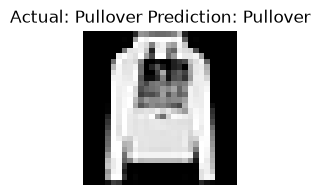

In [121]:
import random

classes = test_data.classes

def vis_sample(image,label,pred):
    plt.figure(figsize=(2,2))
    plt.imshow(image.squeeze(),cmap = "gray")
    plt.title(f"Actual: {label} Prediction: {pred}")
    plt.axis("off")
    plt.show()

model.eval()
random_idx = random.randint(0,len(test_data))
x,y = test_data[random_idx][0], test_data[random_idx][1]
with torch.no_grad():
    x = x.to(device)
    pred = model(x)
    predicted, act = classes[pred[0].argmax(0)], classes[y]
    vis_sample(x.cpu(),act,predicted)

